# Overview

This notebook evaluates the NMS-optimized detector's performance across multiple frames.

It computes key metrics (precision, recall, F1), assesses  localization and classification. Results are stored in a DataFrame for further analysis.

The evaluation Intersection over Union (eval-IoU) threshold can be adjusted and re-run the notebook with the desired value.

This notebook requires the `general` environment (kernel). See ./envs/README.md for more information.

In [1]:
import os
import json
import time
import git
import pandas as pd
# Import helper functions from model_performance_utils.py
from model_performance_utils import *

# Get the path to the project folder
prj_path = git.Repo('.', search_parent_directories=True).working_tree_dir
print(f"Root path of the project:\n'{prj_path}'")

Root path of the project:
'/scratch/vs66tavy/smartphone-insect-detect'


Set the evaluation IoU between a ground truth and a predicted box:

In [2]:
iou_threshold = 0.5 # or 0.1

# Read box data

## - Ground truth (GT)

In [3]:
file_path = os.path.join(prj_path, 'data', 'processed', 'df_roi.feather')
df_true = pd.read_feather(file_path)

df_true.sort_values(by=['new_filename', 'id_box'], inplace=True)
df_true.reset_index(drop=True, inplace=True)

In [4]:
# Define a mapping dictionary for naming the arthropod groups
rename_map = {
    "araneae":       "other",
    "coleoptera":    "other",
    "diptera":       "diptera",
    "hemiptera":     "other",
    "hymenoptera":   "hymenoptera",
    "hymenoptera_f": "other",
    "lepidoptera":   "other",
    "orthoptera":    "other"
}

df_true['true_group'] = df_true['p1_labels'].map(rename_map)

# Display value counts to verify
print(df_true[["true_group"]].value_counts())

true_group 
hymenoptera    13412
other           6401
diptera         5025
Name: count, dtype: int64


## - Predictions (pred)

In [5]:
pred_json_file = os.path.join(prj_path, 'detectors', 'predictions', 'yolov5s', 
                              'conf_0.201918_iou_0.3.json')

with open(pred_json_file, 'r') as f:
    pred_json_data = json.load(f)

df_pred = pd.DataFrame([{
    "pred_image_id": item["image_id"],
    "new_filename": item["file_name"],
    "x": item["bbox"][0],
    "y": item["bbox"][1],
    "width": item["bbox"][2],
    "height": item["bbox"][3],
    "yolo_conf": item["score"],
    "yolo_label_id": item["category_id"]
} for item in pred_json_data])    

In [6]:
# Add the category name to predictions based on a mapping

label_dict = {
    0: 'araneae',
    1: 'coleoptera',
    2: 'diptera',
    3: 'hemiptera',
    4: 'hymenoptera_f',
    5: 'hymenoptera',
    6: 'lepidoptera',
    7: 'orthoptera'
}

groups_dict = {
    0: 'other',
    1: 'other',
    2: 'diptera',
    3: 'other',
    4: 'other',
    5: 'hymenoptera',
    6: 'other',
    7: 'other'
}

df_pred['yolo_label_name'] = df_pred['yolo_label_id'].map(label_dict)

df_pred['yolo_group'] = df_pred['yolo_label_id'].map(groups_dict)

df_pred[["yolo_group"]].value_counts()

yolo_group 
hymenoptera    8735
diptera        4547
other          3638
Name: count, dtype: int64

# Instance (Box) Localization
This section describes the process of class-agnostic insect instance localization.

## Matching Ground Truths (GTs) to Predictions
The goal is to match GT boxes with predicted boxes based on the given eval-IoU, ignoring predicted labels.

IoU matching process:

- A predicted box can match multiple GT boxes, and vice versa.
- We aim to find the "best match" for each predicted box to each GT box.
- Keep predicted boxes with an IoU above eval-IoU for a given GT box.
- From these candidates, select the box with the highest YOLO confidence score.
- If a selected predicted box has already been assigned to a GT box, skip it to ensure each predicted box is assigned to at most one GT box.

Therefore:
- **True Positive (TP)**: a GT box matched to a predicted box above the eval-IoU threshold and with the highest YOLO confidence score (if multiple IoU matches exist).
- **False Negative (FN)**: a GT box not matched to any predicted box (model didn't localize successfully).
- **False Positive (FP)**: a predicted box not matched to any GT box (model hallucinates, overshoots / IoU is too low, or too many predictions for the same GT).


The `match_predictions_to_ground_truth()` function, imported from `model_performance_utils.py`, handles the GT-predictions matching:

- Calculates IoU between each GT box and predicted boxes for each image.
- If no IoU value exceeds the threshold for a GT box, assigns NaN to that GT row in `df_true` data frame to mark a FN.
- If at least one IoU value is above the eval-IoU threshold, selects the prediction with the highest YOLO confidence score and associates it with the GT box, marking a TP in `df_true`.
- "Free floating" predicted boxes not associated with any GT box are marked as FPs in `df_pred`. FPs can only be defined in `df_pred` as it contains all predictions.
- TPs and FNs are computed on the updated `df_true` (ground truth data frame) based on the matching information from `match_predictions_to_ground_truth()`. They cannot be defined on `df_pred` as it lacks information about all GTs.
- The `keep_seq == TRUE` filter (for TPs) excludes 182 background insects.

In [7]:
# Compute the 2nd corner of the boxes - needed for IoU calculations
df_true['x2'] = df_true['x'] + df_true['width']
df_true['y2'] = df_true['y'] + df_true['height']

df_pred['x2'] = df_pred['x'] + df_pred['width']
df_pred['y2'] = df_pred['y'] + df_pred['height']

In [8]:
start_time = time.time()

# This function modifies the df_true and df_pred DataFrames in place.
# It was imported from model_performance_utils.py
match_predictions_to_ground_truth(df_true, df_pred, iou_threshold)

end_time = time.time()
print(f"Process took {round((end_time - start_time) / 60, 1)} minutes.")
# ~ 2 min 

Process took 1.5 minutes.


In [9]:
# Compute FPs:

# FP is any extra predicted box that was not matched to a ground truth box.
# Must be computed on df_pred as it contains all the predictions.
df_pred['box_type'] = pd.Series(dtype='object') # Initialise with NaNs
mask_fp = (df_pred['idx_matched'] == False)
df_pred.loc[mask_fp, 'box_type'] = 'FP'


# Compute TPs and FNs:

# Initialise with NaNs
df_true['box_type'] = pd.Series(dtype='object')

# TP: GT box that was matched to a predicted one - note the .notnull()
mask_tp = df_true['pred_idx'].notnull()
df_true.loc[mask_tp, 'box_type'] = 'TP'

# FN: GT box without any match - note the .isnull()
mask_fn = df_true['pred_idx'].isnull()
df_true.loc[mask_fn, 'box_type'] = 'FN'

In [10]:
# One of the 182 background insects was detected, but all will be dropped from
# the analysis anyways.
# Filter for background insects
mask_background_insects = (df_true['keep_seq'] == False)
print(f"Number of background insects: {mask_background_insects.sum()}")
# And those that got a TP:
mask_bg_insect_tp = (df_true['keep_seq'] == False) & (df_true['box_type'] == 'TP')
count = mask_bg_insect_tp.sum()
print(f"Number of background insect TPs: {count}")
print( df_true.loc[mask_bg_insect_tp, ['id_raw', 'new_filename']] )

# I have also inspected the images with background insects and none of the FPs
# in df_pred are triggered by them (just 6 cases of FPs below, all "genuine"
# FPs)
# Get unique 'new_filename' values for background insects
unique_background_filenames = df_true.loc[mask_background_insects, 'new_filename'].unique()
# I visually checked these cases:
df_pred_check_bg_fps = df_pred[df_pred['new_filename'].isin(unique_background_filenames) & 
                               (df_pred['box_type'] == 'FP')]

# Finally, drop the background insects from df_true: keep only the rows with
# keep_seq = True
df_true = df_true[df_true['keep_seq'] == True]

Number of background insects: 182
Number of background insect TPs: 1
       id_raw        new_filename
20862   30859  img_crop_20034.jpg


In [11]:
# How many TP, FP, FN?
# The correct counts of TPs & FNs are the ones from df_true.
# The correct counts of FPs are the one from df_pred.
mask_fps = (df_pred['box_type'] == 'FP')
print(f"FP     {mask_fps.sum()}")
print(df_true['box_type'].value_counts(dropna=False))

FP     2265
box_type
TP    14654
FN    10002
Name: count, dtype: int64


In [12]:
tp = df_true['box_type'].value_counts(dropna=False)['TP']
fp = df_pred['box_type'].value_counts(dropna=False)['FP']
fn = df_true['box_type'].value_counts(dropna=False)['FN']

precision = tp / (tp + fp) # = from all predictions, how many are correct?
recall = tp / (tp + fn) # also known as true positive rate
# recall = from all ground truth boxes, how many were detected?
f1 = 2 * (precision * recall) / (precision + recall)

print("Overall box detection, irrespective of label")
print(f"TP: {tp}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"Precision: {round(precision, 3)}")
print(f"Recall: {round(recall, 3)}")
print(f"F1: {round(f1, 3)}")

# False positive as percent of total number of ground truth boxes.
n_rows_true = df_true.shape[0]
print(f"FP/N. ground truth boxes: {round(fp/n_rows_true, 4) * 100} %")

# Number of unique images from df_true
n_img = df_true['path'].nunique()
print(f"FP/N. images: {round(fp/n_img, 4) * 100} %")

print(f"tp + fp: {tp + fp}")
print(f"tp + fn: {tp + fn}") # = n_rows_true
print(f"N ground truth boxes: {n_rows_true} (must be equal with tp + fn)")

Overall box detection, irrespective of label
TP: 14654
FP: 2265
FN: 10002
Precision: 0.866
Recall: 0.594
F1: 0.705
FP/N. ground truth boxes: 9.19 %
FP/N. images: 9.48 %
tp + fp: 16919
tp + fn: 24656
N ground truth boxes: 24656 (must be equal with tp + fn)


## Localization performance metrics

Compute for each category: Diptera, Hymenoptera, and Others.

In [13]:
# Initialize an empty list to store results
results_list = []

pred_labels = sorted(df_pred['yolo_group'].dropna().unique())

for label in pred_labels:
    group_gt = df_true[df_true['true_group'] == label]
    group_pred = df_pred[df_pred['yolo_group'] == label]
    tp = group_gt['box_type'].value_counts(dropna=False).get('TP', 0)
    fn = group_gt['box_type'].value_counts(dropna=False).get('FN', 0)
    fp = group_pred['box_type'].value_counts(dropna=False).get('FP', 0)
    
    precision, recall, f1 = calculate_metrics(tp, fp, fn)
    
    n_img = group_gt['new_filename'].nunique()
    n_rows = len(group_gt)
    
    # Append results to list as dictionaries
    results_list.append({
        'group': label,
        'N_rows': n_rows,
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'Precision': round(precision, 3),
        'Recall': round(recall, 3),
        'F1': round(f1, 3),
        'FP/N_gt': round(fp/n_rows, 3),
        'FP/N_img': round(fp/n_img, 3)
    })

# Convert list of dictionaries to DataFrame
df_box_summary = pd.DataFrame(results_list)

sums = df_box_summary[['N_rows', 'TP', 'FP', 'FN']].sum()
sums['group'] = 'Total'

# Recalculate metrics for total row
# Compute weighted precision and recall
sums['Precision'] = sums['TP'] / (sums['TP'] + sums['FP'])
sums['Recall'] = sums['TP'] / (sums['TP'] + sums['FN'])

# Compute F1 from weighted precision and recall
if (sums['Precision'] + sums['Recall']) > 0:
    sums['F1'] = 2 * (sums['Precision'] * sums['Recall']) / (sums['Precision'] + sums['Recall'])
else:
    sums['F1'] = 0.0

# Compute FP/N_gt and FP/N_img
sums['FP/N_gt'] = sums['FP'] / sums['N_rows']
n_img_total = df_true['new_filename'].nunique()
print(f"n_img_total: {n_img_total}")
sums['FP/N_img'] = sums['FP'] / n_img_total

df_box_summary = pd.concat([df_box_summary, pd.DataFrame([sums])], ignore_index=True)

# display(df_box_summary)
print(df_box_summary.to_string())

n_img_total: 23899
         group  N_rows     TP    FP     FN  Precision    Recall        F1   FP/N_gt  FP/N_img
0      diptera    5018   3082   341   1936   0.900000  0.614000  0.730000  0.068000  0.068000
1  hymenoptera   13254   9275   752   3979   0.925000  0.700000  0.797000  0.057000  0.057000
2        other    6384   2297  1172   4087   0.662000  0.360000  0.466000  0.184000  0.186000
3        Total   24656  14654  2265  10002   0.866127  0.594338  0.704943  0.091864  0.094774


In [14]:
# Sum of FP in df_box_summary must be the same as the overall fp computed above
print( sums['FP'] )
print( df_pred['box_type'].value_counts(dropna=False)['FP'] )

# Same for TP
print( sums['TP'] )
print( df_true['box_type'].value_counts(dropna=False)['TP'] )

# Same for FN
print( sums['FN'] )
print( df_true['box_type'].value_counts(dropna=False)['FN'] )

2265
2265
14654
14654
10002
10002


# Sequence (individual insect) localization

An individual insect was considered localized if it got at least one TP box across the consecutive frames in which it appears.

In [15]:
# There are 1281 individual insects in the OOD dataset
total_seq_ids = df_true['seq_id'].nunique()
print(f"Unique sequences (individual insects): {total_seq_ids}")

Unique sequences (individual insects): 1281


In [16]:
# Compute the ratio of boxes detected for each seq_id

# Ratios dict will contain the seq_id as key and the ratio as value
ratios = {}
unique_seq_ids = df_true['seq_id'].unique()

for seq_id in unique_seq_ids:
    group = df_true[df_true['seq_id'] == seq_id]
    ratio = group['pred_iou'].notna().sum() / len(group)
    ratios[seq_id] = ratio

df_true['box_detected_ratio'] = df_true['seq_id'].map(ratios)

seq_ids_with_detected_boxes = df_true[df_true['box_detected_ratio'] > 0]['seq_id'].nunique()

ratio = round(seq_ids_with_detected_boxes / total_seq_ids, 3)

print(f"Nr. seq_id with at least 1 box detected (box_detected_ratio > 0): {seq_ids_with_detected_boxes}")
print(f"Proportion seq_id detected: {ratio}")

Nr. seq_id with at least 1 box detected (box_detected_ratio > 0): 1110
Proportion seq_id detected: 0.867


In [17]:
total_counts = df_true.groupby('true_group')['seq_id'].nunique()
detected_counts = df_true[df_true['box_detected_ratio'] > 0].groupby('true_group')['seq_id'].nunique()
proportions = detected_counts / total_counts

# Create a dataframe to present the results.
# In this case any detected individual is TP and any undetected individual is FN.
# Recall = TP/(TP+FN) = TP/Total indiv. = proportion of detected individuals.
result_df = pd.DataFrame({'N indiv.': total_counts, 
                          'TP': detected_counts,
                          'FN': total_counts - detected_counts, 
                          'Detection rate, %': round(proportions * 100, 2)})

result_df = result_df.sort_values(by='N indiv.', ascending=False)
print(result_df)

             N indiv.   TP  FN  Detection rate, %
true_group                                       
hymenoptera      1013  924  89              91.21
diptera           145  117  28              80.69
other             123   69  54              56.10


# Classification

Check if the predicted label matches the ground truth label.

"Max. confidence" rule = if a sequence has multiple predicted TP boxes, then the final predicted label is the one with the highest confidence score.

In [18]:
# Initialize a dictionary to store the label and the row ID of the max
# confidence prediction for each seq_id
label_and_row_id = {}

for seq_id, group in df_true.groupby('seq_id'):
    non_null_group = group.dropna(subset=['pred_conf'])
    if len(non_null_group) > 0:
        # Get the index of the row with the maximum prediction confidence
        max_conf_idx = non_null_group['pred_conf'].idxmax()
        # Get the label associated with the maximum prediction confidence
        max_conf_label = non_null_group.loc[max_conf_idx, 'pred_label']
        # Store the label and the row ID (index) in the dictionary
        label_and_row_id[seq_id] = (max_conf_label, max_conf_idx)

# Map the label to each row based on seq_id
df_true['common_label'] = df_true['seq_id'].map(lambda x: label_and_row_id[x][0] if x in label_and_row_id else None)

# Create a new column to mark the row with the maximum prediction confidence
# within each sequence group.
# Initially set all values to False
df_true['is_max_conf_row'] = False
# Mark the row with the maximum prediction confidence as True
for seq_id, row_id in label_and_row_id.values():
    df_true.at[row_id, 'is_max_conf_row'] = True

In [19]:
# Mark if the label was matched or not.
# It will return NaN when encounters NaN values in pred_label
df_true['label_matched'] = np.where(df_true['pred_label'].isnull(), 
                                    np.nan, 
                                    df_true['pred_label'] == df_true['p1_labels'])

In [20]:
# Define data frame with ground truths and predicted labels for plotting
cols = ['seq_id','p1_labels', 'common_label', 'true_group']
df_seq = df_true[cols].drop_duplicates(cols)

# Apply mapping to df_true
df_seq['yolo_group'] = df_seq['common_label'].map(rename_map)

# Display value counts to verify
print(df_seq[["true_group"]].value_counts())

true_group 
hymenoptera    1013
diptera         145
other           123
Name: count, dtype: int64


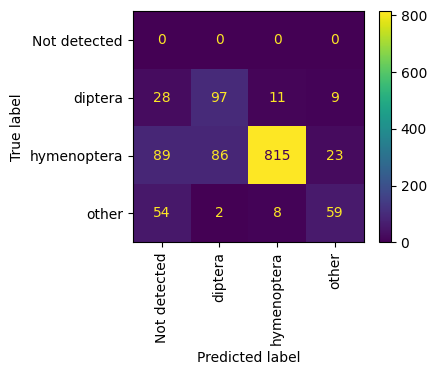

In [21]:
# Get the ground truth and predicted labels
y_true = df_seq['true_group'].astype(str)
y_pred = df_seq['yolo_group'].astype(str)

# Replace NaN values in y_pred
y_pred = np.where(y_pred == 'nan', 'Not detected', y_pred)

fig, ax = plt.subplots(figsize=(4, 3))

# Create a ConfusionMatrixDisplay object
cm_plot = ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=ax,
                                                  xticks_rotation='vertical')
# The row sums except the values on the main diagonal, add up to be the FN

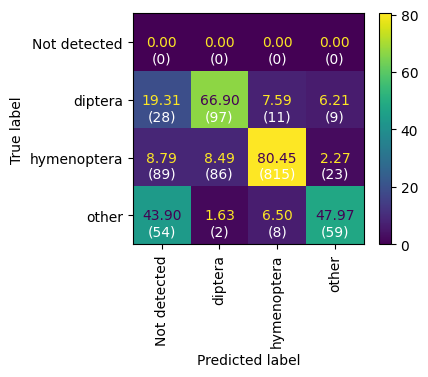

In [22]:
plot_confusion_matrix_custom(y_true, y_pred)

In [23]:
print( compute_metrics(df_seq, df_true, 'true_group', 'yolo_group', dec=4) )

      Category  N.seq  N.box   TP   FP   FN  Precision  Recall      F1
0  hymenoptera   1013  13254  815   19  198     0.9772  0.8045  0.8825
1      diptera    145   5018   97   88   48     0.5243  0.6690  0.5879
2        other    123   6384   59   32   64     0.6484  0.4797  0.5514
3        Total   1281  24656  971  139  310     0.8944  0.7580  0.8205


In [24]:
results_p1_labels = compute_confusion_metrics(df_seq, df_true, 'true_group', 'yolo_group', dec=4)
print(results_p1_labels.to_string(index=True))

      Category  N.box  N.insect  N.insect%  N.detected   TP   FP   FN    TN  Precision  Recall/TPR/Sensitivity      F1  Accuracy  Specificity/TNR
0  hymenoptera  13254      1013      79.08         924  815   19  198   249     0.9772                  0.8045  0.8825    0.8306           0.9291
1      diptera   5018       145      11.32         117   97   88   48  1048     0.5243                  0.6690  0.5879    0.8938           0.9225
2        other   6384       123       9.60          69   59   32   64  1126     0.6484                  0.4797  0.5514    0.9251           0.9724
3        Total  24656      1281     100.00        1110  971  139  310  2423     0.8944                  0.7580  0.8205    0.8468           0.9325


# Save results

In [ ]:
# Table for manuscript

# rest index
result_df2 = results_p1_labels.reset_index(drop=True)

# Compute detection rate = N.detected / N.seq.
result_df2['Localisation-Recall'] = round(result_df2['N.detected'] / result_df2['N.insect'], 4)

# Keep only these columns: Category, N.seq., N.detected, Precision, Recall/TPR/Sensitivity, F1
cols_to_keep = ['Category', 'N.insect', 'N.detected', 'Localisation-Recall', 'Precision', 'Recall/TPR/Sensitivity', 'F1']
result_df2 = result_df2[cols_to_keep]
# Rename 'Recall/TPR/Sensitivity' to 'Recall'
result_df2 = result_df2.rename(columns={'Recall/TPR/Sensitivity': 'Recall'})

# Save to CSV file for manuscript
filename = f'Table_yolov5s_metrics_iou_{iou_threshold}.csv'
file_path = os.path.join(prj_path, 'results', 'tables', filename)
result_df2.to_csv(file_path, index=False)

print(result_df2.to_string(index=True))

      Category  N.insect  N.detected  Localisation-Recall  Precision  Recall      F1
0  hymenoptera      1013         924               0.9121     0.9772  0.8045  0.8825
1      diptera       145         117               0.8069     0.5243  0.6690  0.5879
2        other       123          69               0.5610     0.6484  0.4797  0.5514
3        Total      1281        1110               0.8665     0.8944  0.7580  0.8205


In [26]:
# Table with TPs and FNs:
filename = f'df_eval_seq_yolov5s_iou_{iou_threshold}.feather'
file_path = os.path.join(prj_path, 'data', 'processed', filename)
df_true.reset_index(drop=True).to_feather(file_path)

# Table with FPs:
filename = f'df_pred_seq_yolov5s_iou_{iou_threshold}.feather'
file_path = os.path.join(prj_path, 'data', 'processed', filename)
df_pred.reset_index(drop=True).to_feather(file_path)